In [1]:
from spyplotter import Spectrum
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
%matplotlib widget

# Initialization of a Spectrum

You can either create a spectrum from two arrays directly:

In [2]:
spectrum = Spectrum([1,2,3],[5,6,7])

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


or read it from a *.plot file from a PoWR model:

In [3]:
spectrum_contplines = Spectrum.from_powr(filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=['OPT'],dataset=3)

spyplotter.spectrum - INFO - Flux calibrated spectrum at 10 pc. Thus using erg / (Angstrom s cm2) as y unit.


Dataset 3 corresponds to the spectrum that contains continuum + lines.

You can also read an observed spectrum from a table file (e.g. csv) with numpy or pandas and then create a Spectrum object:

In [5]:
filename = '../tests/test_data/simulated_spectrum.csv'
data_sim = np.loadtxt(filename, skiprows=1,delimiter=',')
spectrum_sim = Spectrum(data_sim[:,0],data_sim[:,1])

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


# Plot spectrum

When plotting the spectrum, you can choose the flux units and the units for the x-axis by using the common astropy units:

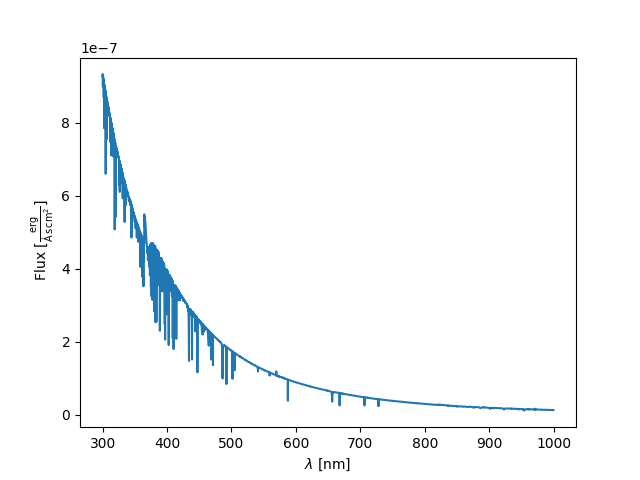

In [8]:
fig = spectrum_contplines.plot(x_unit=u.nm);

You can easily plot another normalized spectrum:

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


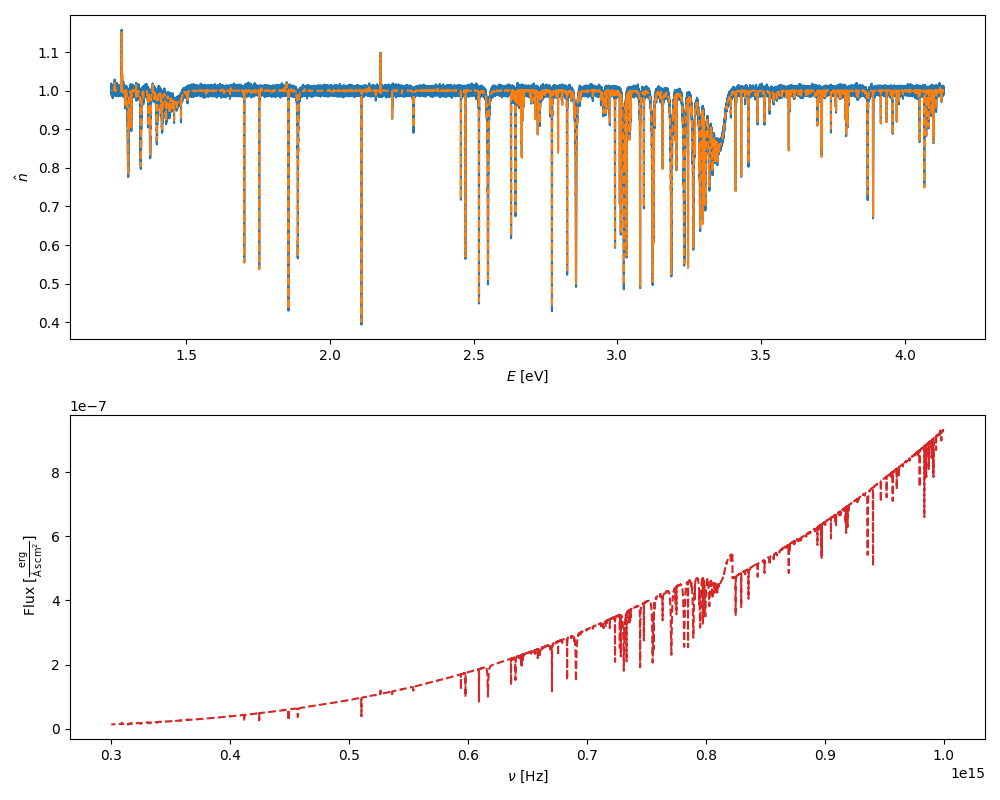

In [11]:
spectrum_norm = Spectrum.from_powr(filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=['OPT'],dataset=1)
fig,ax = plt.subplots(2,1,figsize=(10,8))
spectrum_sim.plot(x_unit=u.eV,ax=ax[0],color='C00',label='Noisy simulated');
spectrum_norm.plot(x_unit=u.eV,ax=ax[0],ls='--',color='C01',label='Model');
spectrum_contplines.plot(x_unit=u.Hz,ax=ax[1],ls='--',color='C03',label='Model');
plt.tight_layout()

# Convert to velocity space